# Training a simple Compocyte classifier with PBMC data.

In this tutorial, you will learn how to train a Compocyte classifier on any data. For simplicity, we will use published PBMC data. However, for your understanding we will go through the process of labelling these cells and fitting a hierarchy to the labels so that Compocyte has everything it needs to work.

## Preprocessing and analysis

In [1]:
import scanpy as sc
import numpy as np

# Load the 10x PBMC dataset
adata = sc.datasets.pbmc3k()

In [2]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

We will make sure to save the count data to .raw, split off 33 % of cells for testing, then normalize, log-transform our data and subset to highly-variable genes. This will improve clustering results.

In [3]:
# Preprocess the data
adata.raw = adata.copy()
# Generate holdout data for testing.
rng = np.random.default_rng(seed=0)
test_adata = adata[rng.choice(adata.obs_names, size=900, replace=False), :].copy()
test_adata.write("./exclude/test_adata.h5ad")
adata = adata[~adata.obs_names.isin(test_adata.obs_names)].copy()
# Normalize to 10,000 counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)
# Log-transform the data
sc.pp.log1p(adata)
# Select the top 2000 highly variable genes for better signal-to-noise ratio upon clustering
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
print('X after preprocessing: ', adata.X[:10, :10])

X after preprocessing:  <Compressed Sparse Row sparse matrix of dtype 'float32'
	with 7 stored elements and shape (10, 10)>
  Coords	Values
  (0, 2)	1.111715316772461
  (0, 4)	1.111715316772461
  (1, 2)	1.4292607307434082
  (2, 2)	1.5663871765136719
  (4, 8)	1.7219784259796143
  (7, 2)	1.6449213027954102
  (8, 2)	1.4576793909072876


In [4]:
# Cluster cells using Leiden clustering after principal component analysis
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

/usr/local/lib/python3.14/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/usr/local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
sc.tl.leiden(adata, resolution=0.8)

/tmp/ipykernel_17908/3412306151.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.8)


## Labelling cell types

In [6]:
sc.tl.umap(adata)

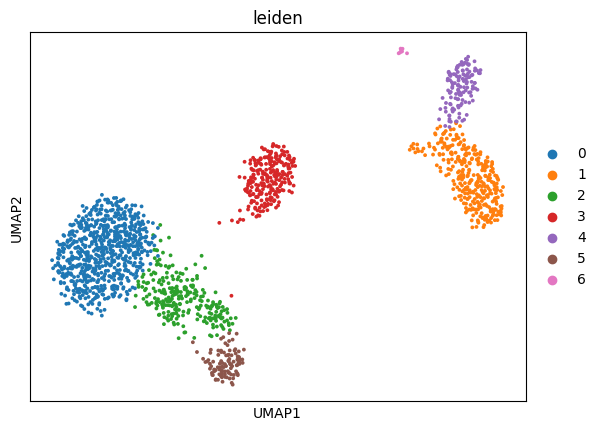

In [7]:
sc.pl.umap(
    adata,
    color=["leiden"],
    size=30,
)

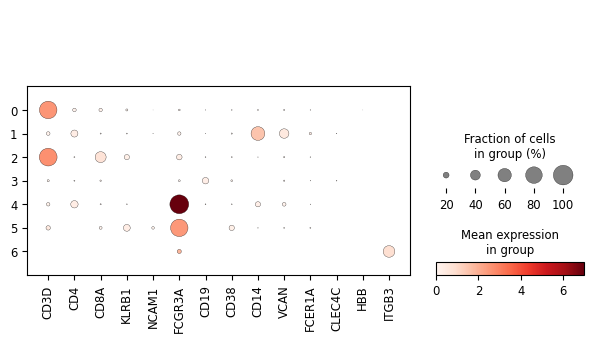

In [8]:
sc.pl.dotplot(adata, var_names=['CD3D', 'CD4', 'CD8A', 'KLRB1', 'NCAM1', 'FCGR3A', 'CD19', 'CD38', 'CD14', 'VCAN', 'FCER1A', 'CLEC4C', 'HBB', 'ITGB3'], groupby='leiden')

The above is a very simplistic overview of some information that will help us classify the cells present in the dataset: spatial relationships in the gene space by dimensionality reduction with UMAP and gene expression on an aggregated per-cluster level in the dotplot. While one must be careful assigning meaning to spatial relationships on a UMAP during cell-type labelling, these two plots shall suffice for the purpose of cell-type labelling in this short tutorial without any claim to completeness.

In [9]:
# Map Leiden clusters to cell type labels based on the dotplot and known marker genes for each cell type
adata.obs['label'] = adata.obs['leiden'].map(
    {
        '0': 'CD4 T cells',
        '1': 'Classical monocytes',
        '2': 'CD8 T cells', # probably includes both antigen-naive and antigen-experienced B cells
        '3': 'B cells',
        '4': 'Non-classical monocytes',
        '5': 'ILCs', # in the sense of both NK cells and other ILCs
        '6': 'mixed'
    }
)

In [10]:
adata.obs['label'].isna().any()

np.False_

In [11]:
# Removed mixed cluster since it is not a well-defined cell type and would likely introduce noise into the classifier.
adata = adata[adata.obs.label != 'mixed'].copy()

## Building a hierarchy

This is where it gets interesting. We have assigned, by cluster, one label per cell. This is the input data cell type classifiers usually receive. 
To harness the potential of Compocyte's structure, we need to explicitly define a hierarchy on which all above labels can be found. This will help the classifier weight relationships between different cell type labels and define branching points in the classification process that can be modified by exchange or extension down the road.

There is one very important assumption that Compocyte works with that is important to keep in mind when building a hierarchy. For the labels at the bottom of the hierarchy, also called leaf nodes, all **prior labels of this branch must also be true**. I. e. a dendritic cell is also a myeloid cell and it is also a blood cell. A CD8 T cell is also a T cell and it is also a lymphoid cell. 

Violating this assumption will lead to performance issues should you try to build your hierarchy from a more developmental point of view. The point of the hierarchy is to group transcriptomically similar cells into shared classification  branches.

A simple such hierarchy would be:

In [12]:
from Compocyte.core.tools import make_graph_from_edges
import networkx as nx

hierarchy = {
    'Blood': {
        'Lymphoid': {
            'T cells': {'CD4 T cells': {}, 'CD8 T cells': {}},
            'B cells': {},
            'ILCs': {}
        },
        'Myeloid': {
            'Classical monocytes': {}, 'Non-classical monocytes': {},
        },        
    }
}
graph = nx.DiGraph()
make_graph_from_edges(hierarchy, graph)

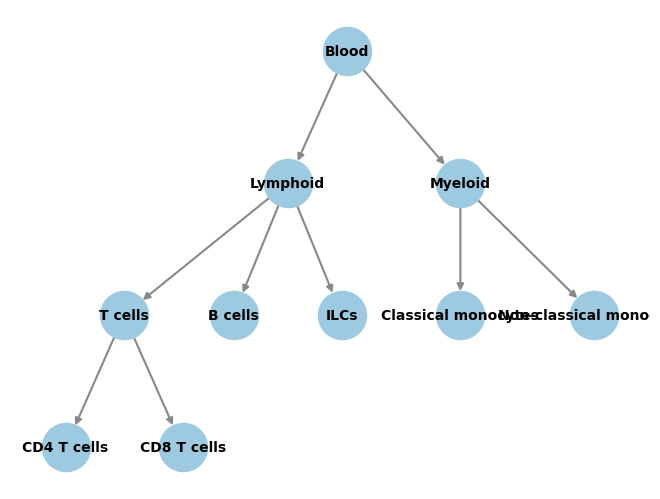

In [13]:
from networkx.drawing.nx_agraph import graphviz_layout

# Plot the graph structure we gave to the classifier during training.
pos = graphviz_layout(
    graph,prog="dot",
    root='Blood',
    args='-Gsplines=curved -Gnodesep=8 -Goverlap=scalexy -Gbeautify=false'
)

nx.draw(
    graph, pos,
    with_labels=True,
    node_color="#9ecae1",
    node_size=1200,
    edge_color="#888",
    width=1.5,
    font_size=10,
    font_weight="bold",
)

## Training the classifier

We have now defined cell type labels and a hierarchy that fits these labels and that can tell how we want our classifier structure to be set up. However there is still a small task to be completed before we can begin training.

To provide training labels for training local classifiers at every branching point, we need to infer the intermediate labels of each cell in the hierarchy. This is done by using the `infer_levels` function takes in the hierarchy, the name of the column in `adata.obs` that contains the cell type labels, the name of the root node in the hierarchy, and the `adata` object itself. It adds the level annnotations as separate obs columns in the provided AnnData object and returns as `obs_names` the column names it used. These can then be passed to the classifier so it knows where to look.

In [14]:
from Compocyte.core.tools import infer_levels

# Save level labels to adata.obs and receive the list of obs columns where they have been saved.
_, obs_names = infer_levels(
    hierarchy=hierarchy, 
    labels='label', 
    root_node='Blood', 
    adata=adata
)

In [15]:
obs_names

['Level_0', 'Level_1', 'Level_2', 'Level_3']

In [16]:
adata.obs

,leiden,label,Level_0,Level_1,Level_2,Level_3
index,,,,,,
AAACATTGAGCTAC-1,3,B cells,Blood,Lymphoid,B cells,
AAACATTGATCAGC-1,0,CD4 T cells,Blood,Lymphoid,T cells,CD4 T cells
AAACCGTGCTTCCG-1,1,Classical monocytes,Blood,Myeloid,Classical monocytes,
AAACGCACTGGTAC-1,0,CD4 T cells,Blood,Lymphoid,T cells,CD4 T cells
AAACGCTGACCAGT-1,2,CD8 T cells,Blood,Lymphoid,T cells,CD8 T cells
...,...,...,...,...,...,...
TTTCGAACACCTGA-1,3,B cells,Blood,Lymphoid,B cells,
TTTCGAACTCTCAT-1,1,Classical monocytes,Blood,Myeloid,Classical monocytes,
TTTCTACTGAGGCA-1,3,B cells,Blood,Lymphoid,B cells,


In [17]:
from Compocyte.core.hierarchical_classifier import HierarchicalClassifier
from Compocyte.core.models.log_reg import LogisticRegression

# Train the hierarchical classifier. This will train a separate classifier for each parent node in the hierarchy.
classifier = HierarchicalClassifier(
    save_path="./exclude/pbmc_classifier", 
    adata=adata, 
    root_node='Blood', 
    dict_of_cell_relations=hierarchy, 
    obs_names=obs_names)
# For training speed, set the classifier type for all nodes to logistic regression. 
# In practice, one would likely want to experiment with different classifier types for different nodes in the hierarchy.
# The default is a 2-layer FCNN with 64 nodes each.
for node in classifier.graph.nodes:
    classifier.set_classifier_type(node, LogisticRegression)

classifier.train_all_child_nodes()

/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  40  197  229  426  440  484  554  882  951  978 1084 1195 1341 1414
 1446 1467 1639 1712 1864 1870 1942] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Training at Blood.


/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  24   40   67  127  151  168  186  197  207  216  229  233  243  277
  283  313  321  339  412  426  440  455  473  484  516  549  554  560
  568  661  681  707  726  794  851  882  901  902  937  940  951  961
  969  978  990 1015 1019 1024 1054 1084 1123 1131 1150 1184 1195 1196
 1206 1207 1219 1259 1289 1321 1341 1349 1397 1411 1414 1431 1446 1467
 1491 1504 1524 1535 1607 1639 1652 1674 1677 1697 1699 1712 1713 1755
 1765 1832 1864 1870 1873 1882 1899 1906 1915 1942] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Training at Lymphoid.


/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  11   12   22   24   40   47   52   67   81   90  107  115  127  151
  168  186  189  197  207  216  226  229  231  233  237  239  243  267
  277  280  283  304  313  315  317  318  321  325  328  339  347  354
  362  364  398  399  412  423  426  437  440  455  473  484  494  515
  516  529  532  549  554  560  562  568  573  587  591  629  661  681
  690  707  719  722  726  744  746  749  767  781  788  794  805  807
  843  851  870  882  885  889  896  901  902  924  937  940  949  951
  961  969  974  978  982  990  999 1014 1015 1018 1019 1022 1024 1050
 1053 1054 1059 1060 1076 1084 1100 1123 1131 1132 1150 1151 1152 1153
 1154 1182 1184 1194 1195 1196 1198 1199 1206 1207 1214 1219 1223 1230
 1240 1259 1273 1278 1280 1289 1301 1321 1341 1343 1344 1349 1375 1385
 1386 1397 1410 1411 1414 1426 1431 1436 1446 1450 1461 1467 1474 1475
 1491 1504 1520 1524 1535 1541

Training at T cells.
Training at Myeloid.


/usr/local/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [   1    6   11   12   18   26   30   40   41   48   52   57   61   77
   79   84   90   92   96  100  101  103  104  107  108  115  117  131
  136  166  170  176  178  179  185  188  189  191  197  208  209  219
  226  229  231  237  239  253  254  258  266  267  275  276  278  285
  286  289  306  315  317  318  325  328  337  354  364  381  398  399
  403  406  407  411  422  423  424  426  429  438  440  441  447  459
  467  471  472  480  484  494  508  510  530  541  546  551  554  557
  565  573  584  587  591  598  611  619  620  629  631  671  672  692
  711  719  722  732  742  744  749  756  758  761  764  767  781  784
  788  805  807  808  812  814  838  843  846  847  848  849  850  852
  861  864  870  880  882  885  887  894  895  896  909  912  941  945
  949  951  954  964  974  978  979  982  991 1002 1014 1018 1022 1029
 1032 1056 1057 1059 1060 1063

In [18]:
# Make sure the classifier has been trained by predicting on the test data. 
# This will add columns with predicted labels to adata.obs for each parent node in the hierarchy.
classifier.load_adata(test_adata)
classifier.predict_all_child_nodes('Blood')

Predicting at Blood.
Predicting at Lymphoid.
Predicting at T cells.
Predicting at Myeloid.


In [19]:
classifier.adata.obs

,Level_1_pred,Level_2_pred,Level_3_pred
index,,,
GCTCAAGAACCATG-1,Myeloid,Non-classical monocytes,
TATTTCCTGGTGTT-1,Lymphoid,T cells,CD4 T cells
TATAAGTGTGGTGT-1,Myeloid,Non-classical monocytes,
AGCACTGATGCTTT-1,Myeloid,Classical monocytes,
GAAACAGACATTCT-1,Lymphoid,T cells,CD4 T cells
...,...,...,...
CTTAGACTAAACGA-1,Lymphoid,T cells,CD4 T cells
CTAGAGACTTTGGG-1,Myeloid,Non-classical monocytes,
TCATCAACTGTTCT-1,Myeloid,Classical monocytes,


In [20]:
classifier.save()

Congratulations. You have trained your own Compocyte classifier. Check out the other tutorials to see how it can be used!